In [71]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tensorflow.keras import layers, models
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [72]:
# Load the dataset
df = pd.read_csv('balanced_cleaned_dataset.csv')

# Display the first few rows
df.head()

,id,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,8656,0,icmp,eco_i,SF,18,0,0,0,0,...,57,1.00,0.00,1.00,1.0,0.0,0.0,0.0,0.0,anomaly
1,107849,0,tcp,login,S0,0,0,0,0,0,...,3,0.01,0.07,0.00,0.0,1.0,1.0,0.0,0.0,anomaly
2,3238,0,tcp,http,SF,306,2239,0,0,0,...,225,0.88,0.02,0.00,0.0,0.0,0.0,0.0,0.0,normal
3,48274,0,tcp,domain,S0,0,0,0,0,0,...,10,0.04,0.06,0.00,0.0,1.0,1.0,0.0,0.0,anomaly
4,96195,0,tcp,private,REJ,0,0,0,0,0,...,12,0.10,0.07,0.01,0.0,0.0,0.0,1.0,1.0,anomaly


In [73]:
# Check for missing values
print(df.isnull().sum())

id                             0
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_r

In [74]:
# Dropping any rows with missing values (if needed)
df.dropna(inplace=True)

In [75]:
# Remove duplicate records
df.drop_duplicates(inplace=True)

In [76]:
# Label encoding for the target variable (class)
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

# Save the label encoder to reuse later
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

In [77]:
# One-Hot Encoding for categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)  # drop_first=True avoids multicollineari

In [78]:
# Split the data into features (X) and target variable (y)
X = df_encoded.drop(columns=['class'])
y = df_encoded['class']

In [79]:
# Feature selection using SelectKBest with f_classif (ANOVA F-value)
selector = SelectKBest(score_func=f_classif, k=40)
X_new = selector.fit_transform(X, y)

# Get the top 10 selected features
selected_features = X.columns[selector.get_support()]
print(f"Top 25 Features: {selected_features}")

Top 25 Features: Index(['wrong_fragment', 'logged_in', 'count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_serror_rate', 'dst_host_srv_serror_rate',
       'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'protocol_type_udp',
       'service_Z39_50', 'service_bgp', 'service_courier', 'service_domain_u',
       'service_eco_i', 'service_ecr_i', 'service_ftp_data', 'service_http',
       'service_iso_tsap', 'service_private', 'service_smtp', 'service_uucp',
       'service_uucp_path', 'service_vmnet', 'service_whois', 'flag_REJ',
       'flag_RSTO', 'flag_RSTR', 'flag_S0', 'flag_SF'],
      dtype='object')


c:\Users\1256\.conda\envs\myenv\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [ 6 17 18] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\1256\.conda\envs\myenv\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [80]:
# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)

Epoch 1/50
466/466 [==============================] - 7s 10ms/step - loss: 0.2337 - accuracy: 0.9120 - val_loss: 0.1623 - val_accuracy: 0.9407
Epoch 2/50
466/466 [==============================] - 4s 9ms/step - loss: 0.1522 - accuracy: 0.9438 - val_loss: 0.1427 - val_accuracy: 0.9444
Epoch 3/50
466/466 [==============================] - 4s 9ms/step - loss: 0.1264 - accuracy: 0.9554 - val_loss: 0.1182 - val_accuracy: 0.9605
Epoch 4/50
466/466 [==============================] - 4s 8ms/step - loss: 0.1131 - accuracy: 0.9597 - val_loss: 0.1138 - val_accuracy: 0.9560
Epoch 5/50
466/466 [==============================] - 4s 9ms/step - loss: 0.1077 - accuracy: 0.9601 - val_loss: 0.1063 - val_accuracy: 0.9646
Epoch 6/50
466/466 [==============================] - 4s 8ms/step - loss: 0.1001 - accuracy: 0.9634 - val_loss: 0.1150 - val_accuracy: 0.9640
Epoch 7/50
466/466 [==============================] - 4s 9ms/step - loss: 0.0896 - accuracy: 0.9671 - val_loss: 0.1006 - val_accuracy: 0.9678
Epoch

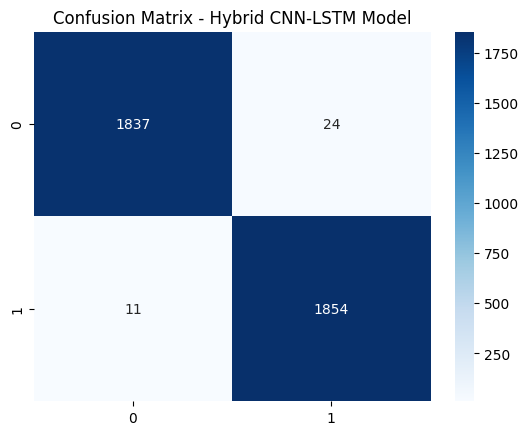

In [81]:
# **Step 1: Hybrid CNN-LSTM Model**

# Reshaping the data for CNN
X_train_cnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))  # (samples, time_steps, features)
X_test_cnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))  # (samples, time_steps, features)

# CNN-LSTM Model
cnn_lstm_model = models.Sequential()

# CNN Layer
cnn_lstm_model.add(layers.Conv1D(64, 3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)))
cnn_lstm_model.add(layers.MaxPooling1D(pool_size=2))

# LSTM Layer
cnn_lstm_model.add(layers.LSTM(50, return_sequences=False))
cnn_lstm_model.add(layers.Dense(1, activation='sigmoid'))

cnn_lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train CNN-LSTM model
cnn_lstm_model.fit(X_train_cnn, y_train, epochs=50, batch_size=32, validation_data=(X_test_cnn, y_test))

# Predictions and confusion matrix for CNN-LSTM model
y_pred_cnn_lstm = (cnn_lstm_model.predict(X_test_cnn) > 0.5)
cm_cnn_lstm = confusion_matrix(y_test, y_pred_cnn_lstm)

# Plot confusion matrix for CNN-LSTM model
sns.heatmap(cm_cnn_lstm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Hybrid CNN-LSTM Model')
plt.show()


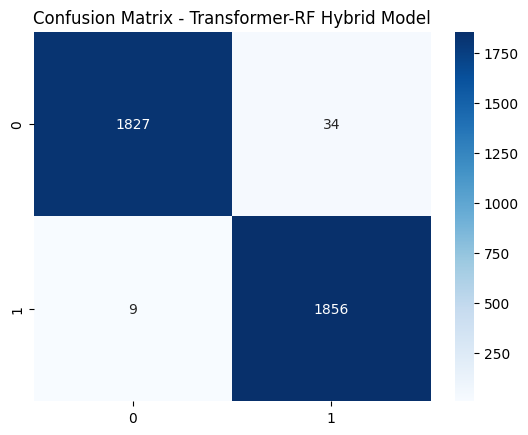

Accuracy of Transformer-RF Hybrid Model: 0.9885


In [82]:
# **Step 2: Transformer-RF Hybrid Model**

# Standardizing the data before feeding into the Transformer
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Transformer Model (simplified using PCA for feature extraction)
pca = PCA(n_components=10)  # Reduce dimensions (emulating feature extraction in transformers)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Random Forest Classifier (Transformer-RF Hybrid)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_pca, y_train)

# Predictions and confusion matrix for Transformer-RF Hybrid Model
y_pred_rf = rf_model.predict(X_test_pca)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot confusion matrix for Transformer-RF Hybrid Model
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Transformer-RF Hybrid Model')
plt.show()

# Calculate accuracy for the Transformer-RF Hybrid Model
from sklearn.metrics import accuracy_score
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# Display accuracy
print(f"Accuracy of Transformer-RF Hybrid Model: {accuracy_rf:.4f}")


In [83]:
import joblib

# Save the CNN-LSTM model
cnn_lstm_model.save('cnn_lstm_model.h5')

# Save the label encoder
joblib.dump(le, 'label_encoder.pkl')

# Save the PCA model (for Transformer-RF Hybrid)
joblib.dump(pca, 'pca_model.pkl')

# Save the Random Forest model (for Transformer-RF Hybrid)
joblib.dump(rf_model, 'rf_model.pkl')


c:\Users\1256\.conda\envs\myenv\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


['rf_model.pkl']

In [84]:
# **Step 3: Model Evaluation**

# Calculate accuracy for both models (optional)
acc_cnn_lstm = accuracy_score(y_test, y_pred_cnn_lstm)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy of CNN-LSTM Model: {acc_cnn_lstm}")
print(f"Accuracy of Transformer-RF Hybrid Model: {acc_rf}")

Accuracy of CNN-LSTM Model: 0.990606548577563
Accuracy of Transformer-RF Hybrid Model: 0.9884594739667203
